# Citation
Refer to Li et al., Arxiv, 2024. Dynamics of Adaptive Continuous Attractor Neural Networks.
https://doi.org/10.48550/arXiv.2410.06517

And https://github.com/Routhleck/canns

<RetrievalTracking1D> Generating Task data: 0it [00:00, ?it/s]

<RetrievalTracking1D> Generating Task data: 210it [00:00, 6043.62it/s]
Running for 210 iterations: 100%|██████████| 210/210 [00:00<00:00, 1870.33it/s]


(210, 2096) (210, 2096)


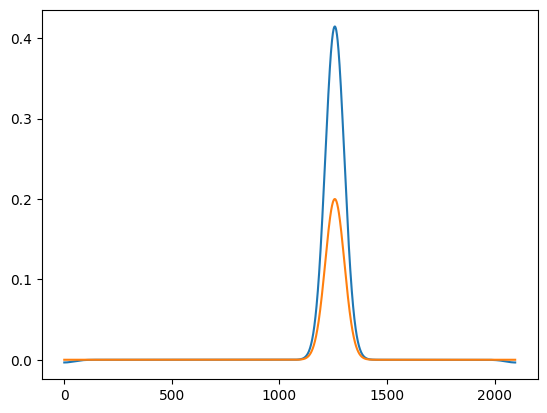

In [ ]:
import brainstate
from canns.models.basic import CANN1D, CANN1D_SFA
from canns.models.basic.cann import BaseCANN1D
from collections.abc import Sequence
from canns.typing import Iext_pair_type, Iext_type, time_type
from canns.task.tracking import SmoothTracking1D, TemplateMatching1D, TrackingTask
import numpy as np

class RetrievalTracking1D(TrackingTask):
    def __init__(
        self,
        cann_instance: BaseCANN1D,
        Iext: Sequence[Iext_type],
        duration: Sequence[time_type],
        time_step: time_type = 0.1,
    ):
        """
        Initializes the Smooth Tracking task.

        Args:
            cann_instance (BaseCANN1D): An instance of the 1D CANN model.
            Iext (Sequence[float | Quantity]): A sequence of keypoint positions for the input.
            duration (Sequence[float | Quantity]): The duration of each segment of smooth movement.
            time_step (float | Quantity, optional): The simulation time step. Defaults to 0.1.
        """
        assert len(tuple(Iext)) == len(tuple(duration)), (
            "Iext must have one more element than duration to define start and end points for each segment."
        )
        super().__init__(
            ndim=1,
            config={
                "cann_instance": cann_instance,
                "Iext": Iext,  # Sequence of keypoint positions for the input.
                "duration": duration,  # Sequence of durations for each segment.
                "time_step": time_step,  # Time step for the simulation.
            },
        )
        
        self.A = cann_instance.A
        
    def _make_Iext_sequence(self):
        """
        Creates a time-series of external input positions that smoothly transitions
        between the keypoints defined in `self.Iext`.
        The output is an array of shape (total_steps, ndim).
        """
        # The output sequence now has a shape of (total_steps, ndim) to hold coordinates.
        Iext_sequence = np.zeros((self.total_steps, self.ndim), dtype=float)
        start_step = 0
        noise = 0.1 * self.A * np.random.randn(*self.shape)

        if self.ndim == 1:
            for i, dur in enumerate(self.duration):
                num_steps = int(dur / self.time_step)
                if num_steps == 0:
                    continue
                end_step = start_step + num_steps
                Iext_sequence[start_step:end_step] = self.Iext[i] + 
                start_step = end_step
            if start_step < self.total_steps:
                Iext_sequence[start_step:] = self.Iext[-1]
        else:
            raise NotImplementedError("Only 1D is implemented in this task.")
        
        return Iext_sequence

brainstate.environ.set(dt=0.1)

cann = CANN1D_SFA(num=2096, z_min=0, z_max=10, a=0.15)
cann.init_state()

task = RetrievalTracking1D(
    cann_instance=cann,
    Iext=(0, 6),
    duration=(1, 20),
    time_step=brainstate.environ.get_dt(),
)
task.get_data()

def step(t, stimulus):
    cann(stimulus)
    return cann.u.value, cann.inp.value

us, inputs = brainstate.compile.for_loop(
    step,
    task.run_steps,
    task.data,
    pbar=brainstate.compile.ProgressBar(10),
)

import matplotlib.pyplot as plt
print(us.shape, inputs.shape)
t = 100
plt.plot(us[t, :])
plt.plot(inputs[t, :])
plt.show()